In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ─── Configurações visuais ────────────────────────────────────────────────────
C0 = "#2ecc71"   # Adimplente
C1 = "#e74c3c"   # Inadimplente
BG = "#f8f9fa"
ACCENT = "#2c3e50"
OUT = "graficos_correlacao/"

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs(OUT, exist_ok=True)

from google.colab import files

---


uploaded = files.upload()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Loan_Default.csv to Loan_Default.csv


In [ ]:
df = pd.read_csv('Loan_Default.csv')

In [ ]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [ ]:

cols = ['income', 'dtir1', 'loan_amount', 'Credit_Score', 'LTV']


stats = df[cols].describe().T


stats['variancia'] = df[cols].var()
stats['assimetria'] = df[cols].skew()
stats['curtose'] = df[cols].kurt()
stats['IQR'] = stats['75%'] - stats['25%']
print(stats)

                 count           mean            std           min  \
income        139520.0    6957.338876    6496.586382      0.000000   
dtir1         124549.0      37.732932      10.545435      5.000000   
loan_amount   148670.0  331117.743997  183909.310127  16500.000000   
Credit_Score  148670.0     699.789103     115.875857    500.000000   
LTV           133572.0      72.746457      39.967603      0.967478   

                       25%           50%            75%         max  \
income          3720.00000    5760.00000    8520.000000   578580.00   
dtir1             31.00000      39.00000      45.000000       61.00   
loan_amount   196500.00000  296500.00000  436500.000000  3576500.00   
Credit_Score     599.00000     699.00000     800.000000      900.00   
LTV               60.47486      75.13587      86.184211     7831.25   

                 variancia  assimetria       curtose           IQR  
income        4.220563e+07   17.307695    885.292460    4800.00000  
dtir1         

In [ ]:

outliers_ltv = df[df['LTV'] > 150][['ID', 'loan_amount', 'property_value', 'LTV', 'Status']]


print("--- Top Outliers de LTV (Auditando erro de digitação) ---")
print(outliers_ltv.sort_values(by='LTV', ascending=False).head(10))

--- Top Outliers de LTV (Auditando erro de digitação) ---
            ID  loan_amount  property_value          LTV  Status
16951    41841       626500          8000.0  7831.250000       0
55286    80176       536500          8000.0  6706.250000       0
47807    72697       416500          8000.0  5206.250000       0
65238    90128       376500          8000.0  4706.250000       0
46287    71177       236500          8000.0  2956.250000       1
123343  148233       186500          8000.0  2331.250000       0
43348    68238       126500         48000.0   263.541667       1
27473    52363        66500         28000.0   237.500000       1
30837    55727        66500         28000.0   237.500000       1
136154  161044       546500        248000.0   220.362903       0


In [ ]:

renda_zero = df[df['income'] == 0]
print(f"Total de clientes com renda ZERO: {len(renda_zero)}")
print(f"Taxa de inadimplência (Status 1) neles: {renda_zero['Status'].mean():.2%}")


print(f"Valor médio do imóvel desses clientes: {renda_zero['property_value'].median()}")

Total de clientes com renda ZERO: 1260
Taxa de inadimplência (Status 1) neles: 99.37%
Valor médio do imóvel desses clientes: 368000.0


In [ ]:

df_clean = df[
    ((df['LTV'] <= 150) | (df['LTV'].isnull())) &
    ((df['income'] > 0) | (df['income'].isnull())) &
    ((df['dtir1'] >= 0) | (df['dtir1'].isnull()))
].copy()

print(f"Base inicial de limpeza criada com {len(df_clean)} linhas.")

Base inicial de limpeza criada com 147377 linhas.


In [ ]:


cols_mediana_simples = ['term', 'age', 'submission_of_application']
for col in cols_mediana_simples:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


cols_moda = ['loan_limit', 'approv_in_adv', 'loan_purpose', 'Neg_ammortization']
for col in cols_moda:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [ ]:

df_clean['property_value'] = df_clean.groupby(['Region', 'occupancy_type'])['property_value'] \
    .transform(lambda x: x.fillna(x.median()))


df_clean['income'] = df_clean.groupby(['Region', 'occupancy_type'])['income'] \
    .transform(lambda x: x.fillna(x.median()))


mask_ltv_nulo = df_clean['LTV'].isnull()
df_clean.loc[mask_ltv_nulo, 'LTV'] = (df_clean['loan_amount'] / df_clean['property_value']) * 100

print(" Preenchimento por agrupamento (Income e Property) concluído!")

 Preenchimento por agrupamento (Income e Property) concluído!


In [ ]:
cols_mice = ['loan_amount', 'Credit_Score', 'income', 'property_value',
             'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'dtir1']

mice_imputer = IterativeImputer(max_iter=10, random_state=42)

#
df_clean[cols_mice] = mice_imputer.fit_transform(df_clean[cols_mice])

In [ ]:

df_clean = df_clean[
    (df_clean['LTV'] <= 150) &
    (df_clean['income'] > 0) &
    (df_clean['dtir1'] >= 0)
].copy()

print(f"Base final limpa e podada: {len(df_clean)} linhas.")
print(f"Máximo LTV real: {df_clean['LTV'].max():.2f}")
print(f"Mínimo DTI real: {df_clean['dtir1'].min():.2f}")

Base final limpa e podada: 146398 linhas.
Máximo LTV real: 149.90
Mínimo DTI real: 1.17


In [ ]:

cols_finais = ['income', 'dtir1', 'loan_amount', 'Credit_Score', 'LTV', 'rate_of_interest']


stats_clean = df_clean[cols_finais].describe().T


stats_clean['variancia'] = df_clean[cols_finais].var()
stats_clean['assimetria'] = df_clean[cols_finais].skew()
stats_clean['curtose'] = df_clean[cols_finais].kurt()
stats_clean['IQR'] = stats_clean['75%'] - stats_clean['25%']


print("--- RESUMO ESTATÍSTICO FINAL (DADOS SANEADOS) ---")
print(stats_clean.round(2))

--- RESUMO ESTATÍSTICO FINAL (DADOS SANEADOS) ---
                     count       mean        std       min        25%  \
income            146398.0    6872.22    6155.85     60.00    3900.00   
dtir1             146398.0      37.85       9.69      1.17      33.00   
loan_amount       146398.0  327755.48  178731.04  16500.00  196500.00   
Credit_Score      146398.0     699.76     115.88    500.00     599.00   
LTV               146398.0      72.22      20.64      0.97      59.53   
rate_of_interest  146398.0       4.04       0.49      2.12       3.75   

                        50%        75%        max     variancia  assimetria  \
income              5640.00    8220.00   578580.0  3.789443e+07       18.72   
dtir1                 38.50      44.00       61.0  9.389000e+01       -0.60   
loan_amount       296500.00  436500.00  3576500.0  3.194478e+10        1.53   
Credit_Score         699.00     800.00      900.0  1.342810e+04        0.01   
LTV                   74.74      86.53     

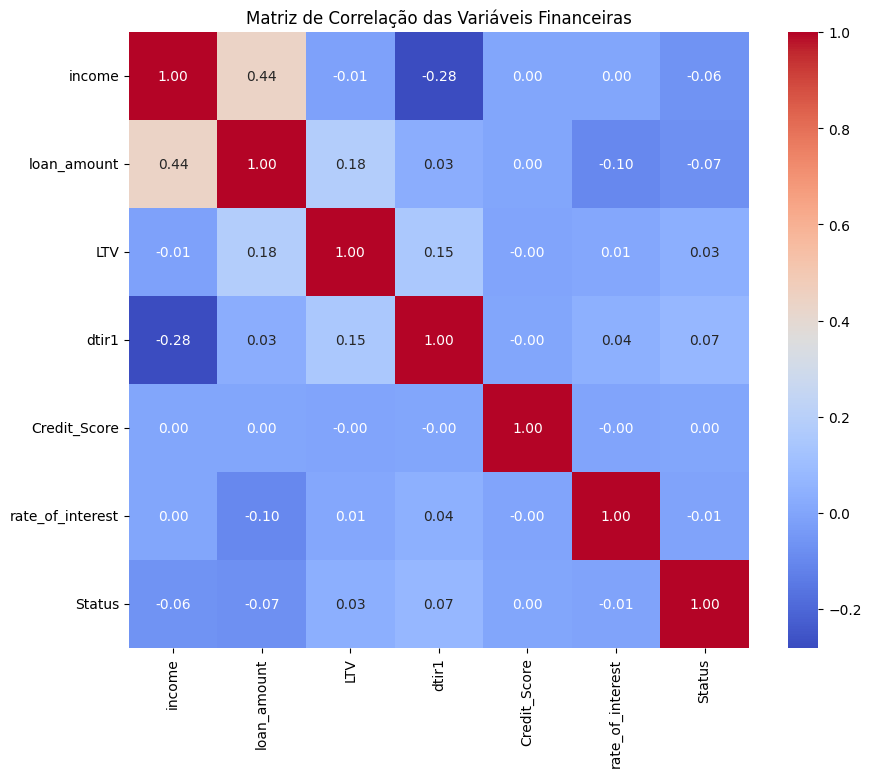

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[['income', 'loan_amount', 'LTV', 'dtir1', 'Credit_Score', 'rate_of_interest', 'Status']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Financeiras")
plt.show()

In [ ]:
# Verificação final: não pode haver nulos
print(df_clean.isnull().sum())

# Salva o arquivo final
df_clean.to_csv('Loan_Final.csv', index=False)

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

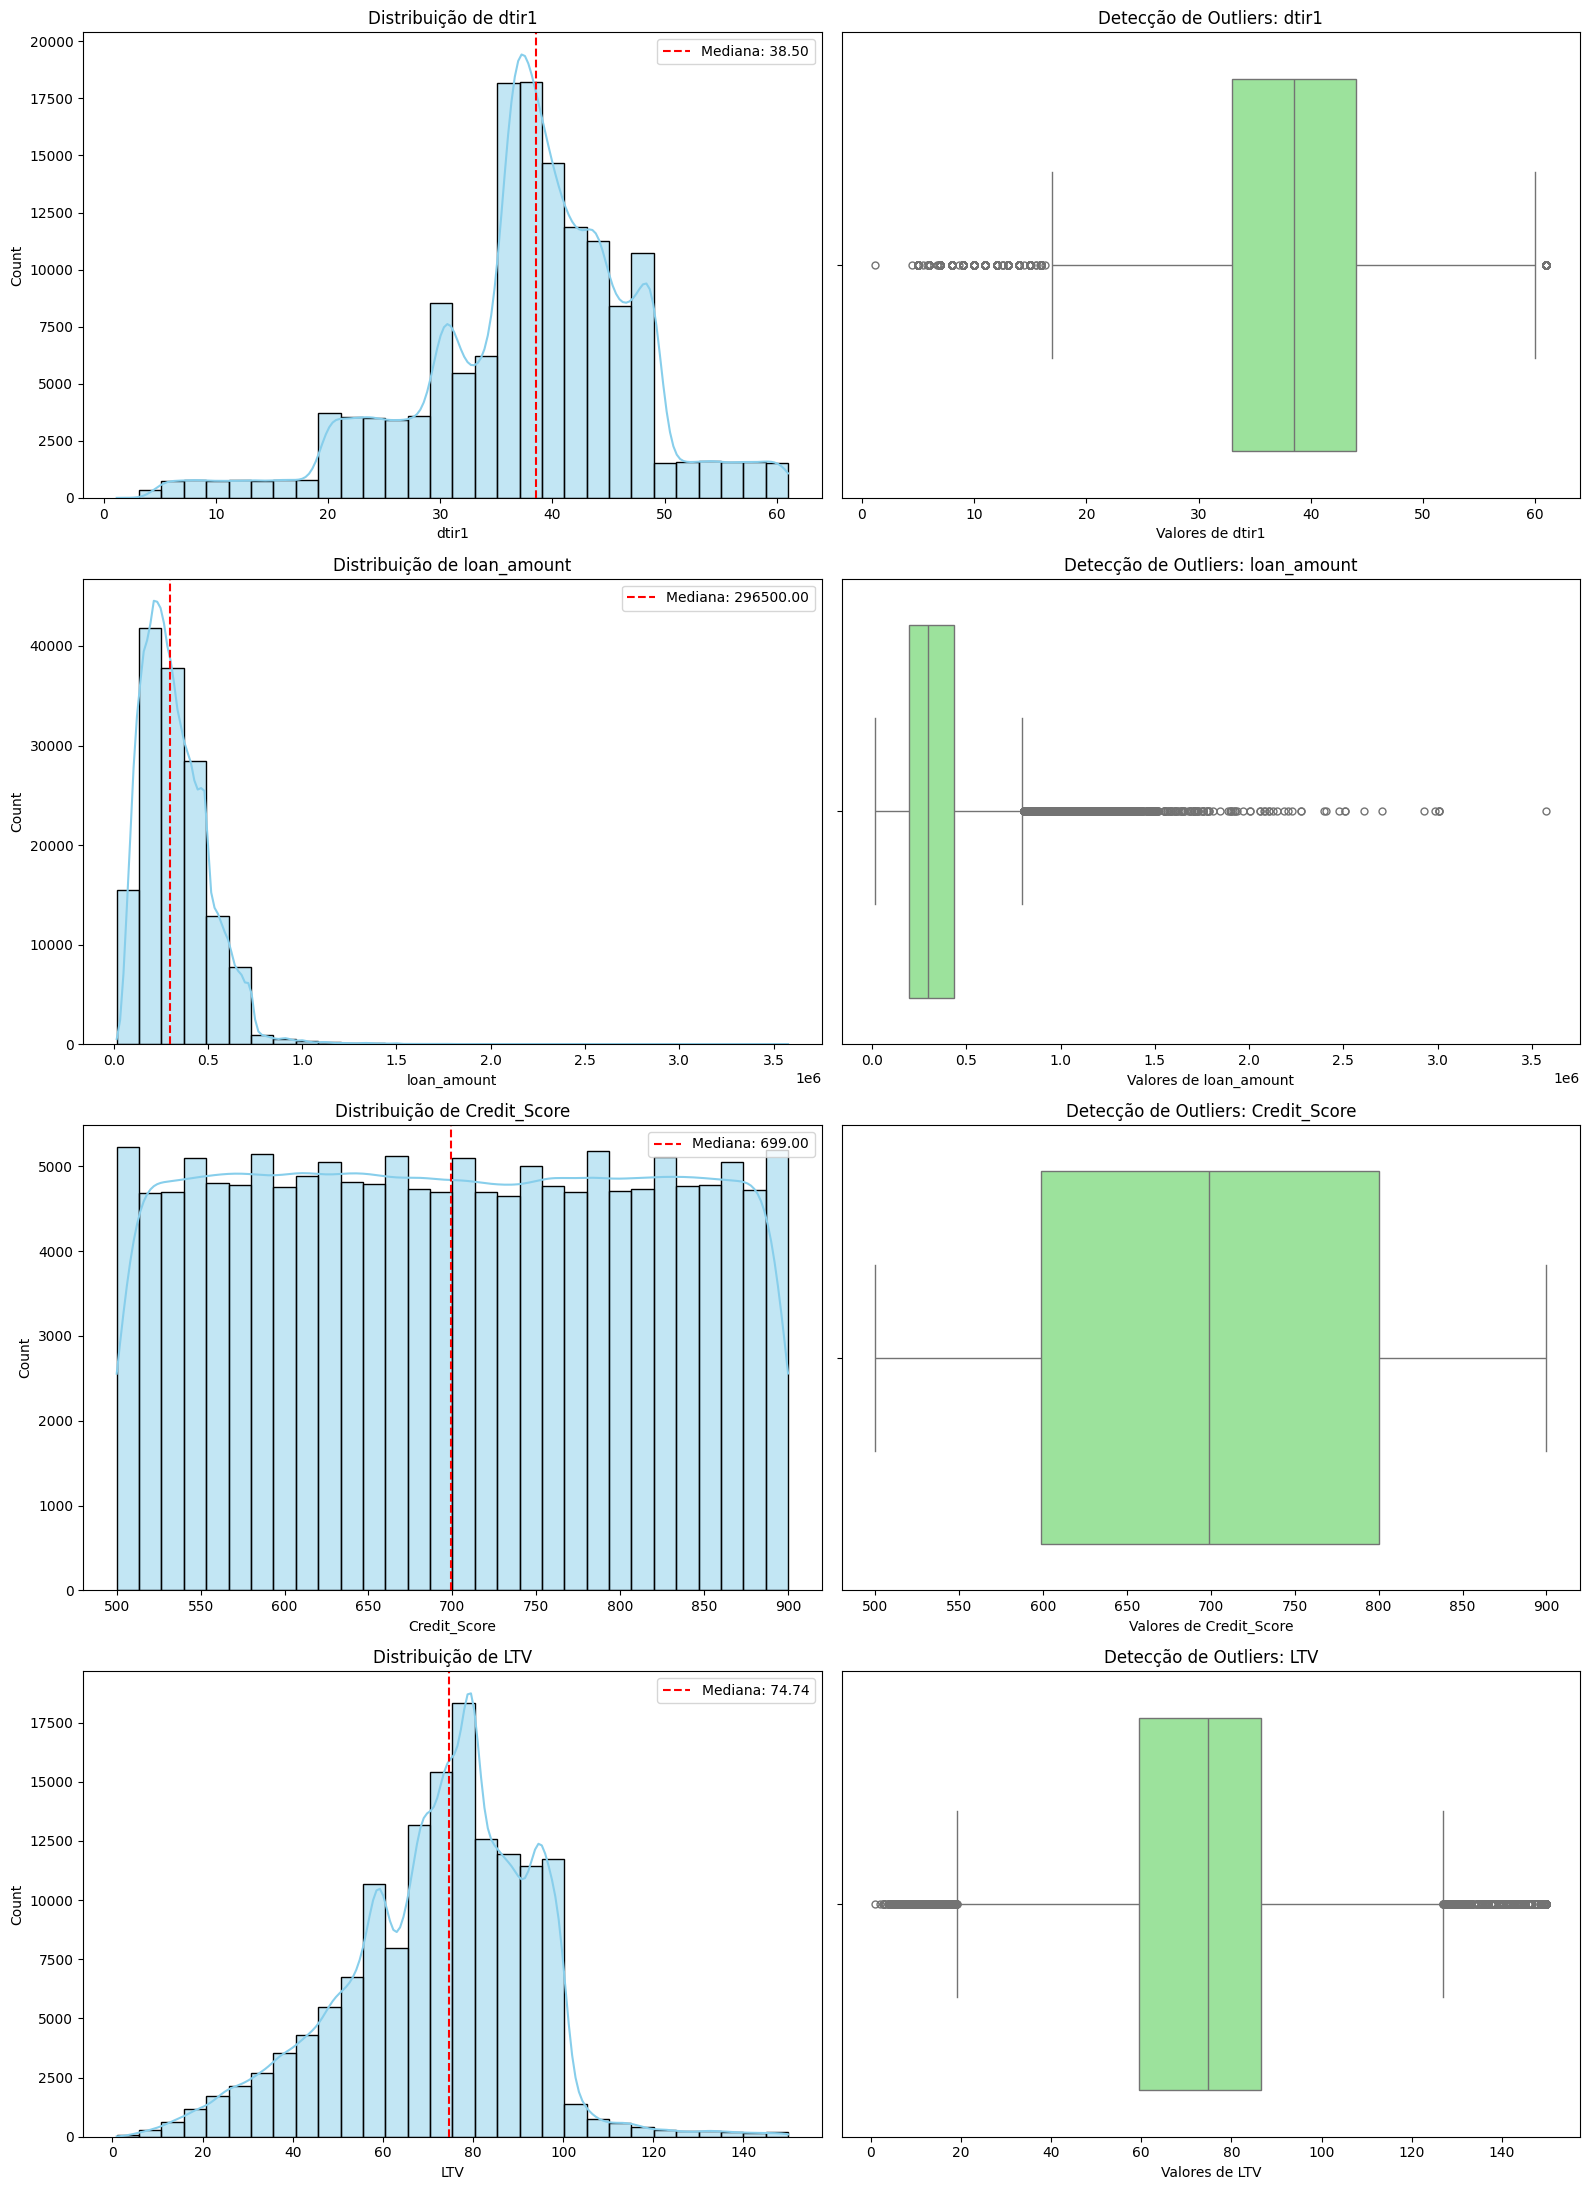

--- Resumo das Medianas (Valores Centrais Reais) ---
dtir1               38.500369
loan_amount     296500.000000
Credit_Score       699.000000
LTV                 74.736148
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Arquivo responsável por validar Simetria, Outliers e Assimetria. Explicação detalhada GitHub


# Carregando o arquivo
df = df_clean

# Definindo as colunas numéricas para análise
cols_analise = ['dtir1', 'loan_amount', 'Credit_Score', 'LTV']

# Configurando a área de desenho
plt.figure(figsize=(16, 22))

for i, col in enumerate(cols_analise):
    # --- 1. Gráfico de Histograma (Padrões e Distribuição) ---
    plt.subplot(len(cols_analise), 2, 2*i + 1)

    # Criando o histograma
    sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=30)

    # Adiciona uma linha vertical para a Mediana
    mediana = df[col].median()
    plt.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana:.2f}')

    plt.title(f'Distribuição de {col}')
    plt.legend()

    # --- 2. Gráfico de Boxplot (Anomalias e Outliers) ---
    plt.subplot(len(cols_analise), 2, 2*i + 2)

    # Criando o boxplot
    sns.boxplot(x=df[col], color='lightgreen', fliersize=5)
    plt.title(f'Detecção de Outliers: {col}')
    plt.xlabel(f'Valores de {col}')

plt.tight_layout()
plt.show()

# Resumo estatístico rápido para conferência no console
print("--- Resumo das Medianas (Valores Centrais Reais) ---")
print(df[cols_analise].median())
#print(df.isnull().sum())

In [ ]:

df = df_clean

# Ver a média de DTIR1 para quem pagou vs quem não pagou
print("Média de comprometimento de renda por Status:")
display(df.groupby('Status')['dtir1'].mean())


# Ver a mediana de LOAN
print("Mediana de loan de renda por Status:")
display(df.groupby('Status')['loan_amount'].median())


#Mediana LTV
print("Mediana de LTV de renda por Status:")
display(df.groupby('Status')['LTV'].median())

print("Media do empréstimo:", df['loan_amount'].mean())
print("Mediana do empréstimo:", df['loan_amount'].median())
print("Mediana do SCORE:", df['Credit_Score'].mean())

Média de comprometimento de renda por Status:


,dtir1
Status,
0,37.452548
1,39.147908


Mediana de loan de renda por Status:


,loan_amount
Status,
0,306500.0
1,266500.0


Mediana de LTV de renda por Status:


,LTV
Status,
0,74.504405
1,76.285047


Media do empréstimo: 327755.48163226276
Mediana do empréstimo: 296500.0
Mediana do SCORE: 699.7583505239143


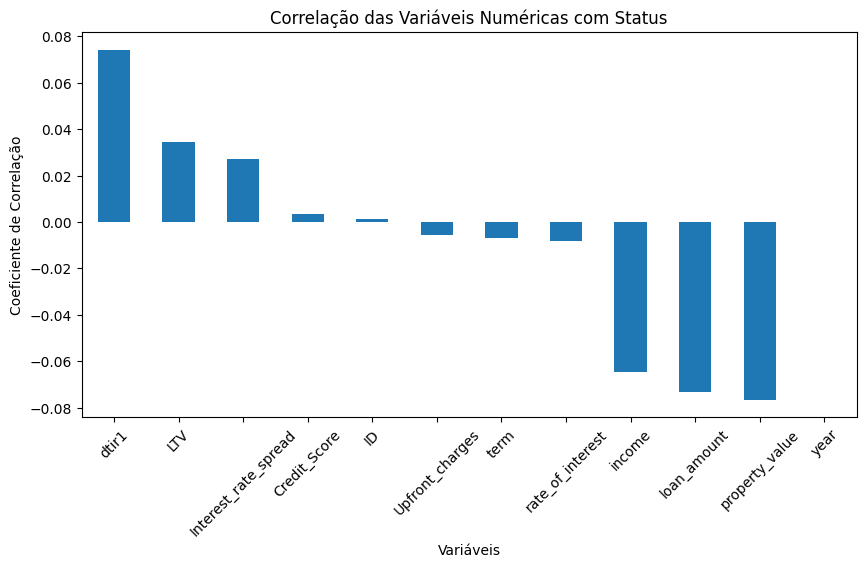

In [ ]:
corr_status = df.corr(numeric_only=True)['Status'].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_status.drop('Status').plot(kind='bar')
plt.title("Correlação das Variáveis Numéricas com Status")
plt.ylabel("Coeficiente de Correlação")
plt.xlabel("Variáveis")
plt.xticks(rotation=45)
plt.show()

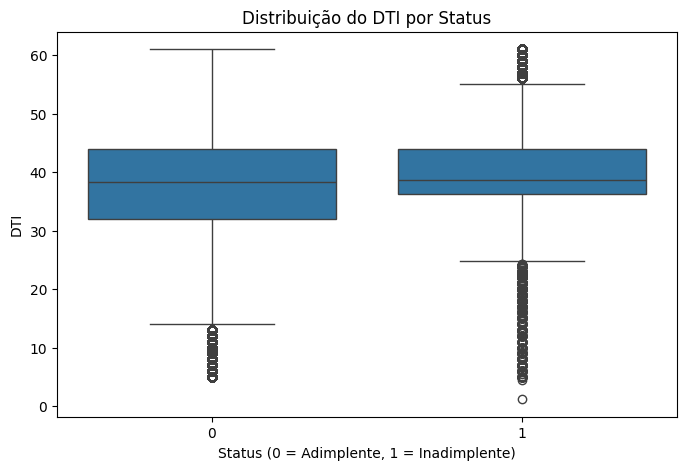

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='dtir1')
plt.title("Distribuição do DTI por Status")
plt.xlabel("Status (0 = Adimplente, 1 = Inadimplente)")
plt.ylabel("DTI")
plt.show()

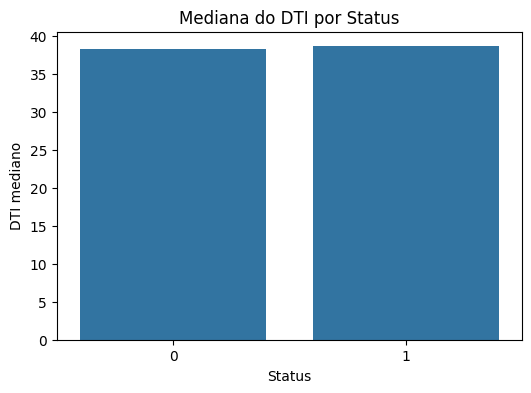

   Status      dtir1
0       0  38.245187
1       1  38.603079


In [ ]:
dti_mediana = df.groupby('Status')['dtir1'].median().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=dti_mediana, x='Status', y='dtir1')
plt.title("Mediana do DTI por Status")
plt.xlabel("Status")
plt.ylabel("DTI mediano")
plt.show()

print(dti_mediana)

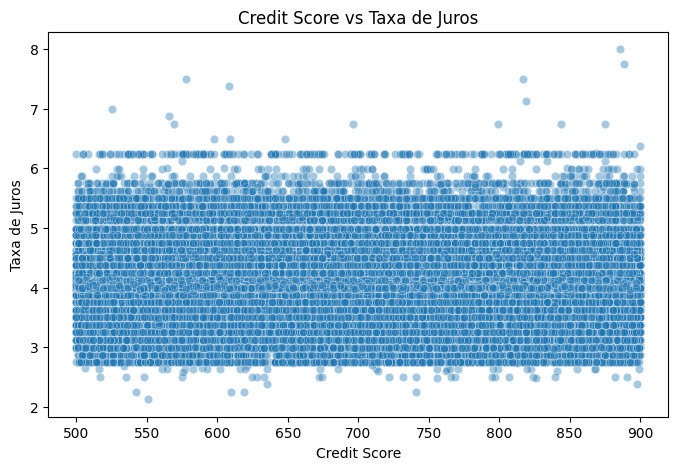

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Credit_Score', y='rate_of_interest', alpha=0.4)
plt.title("Credit Score vs Taxa de Juros")
plt.xlabel("Credit Score")
plt.ylabel("Taxa de Juros")
plt.show()

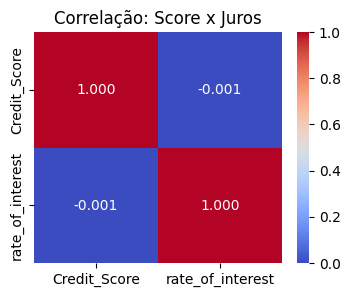

In [ ]:
plt.figure(figsize=(4, 3))
sns.heatmap(df[['Credit_Score', 'rate_of_interest']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlação: Score x Juros")
plt.show()

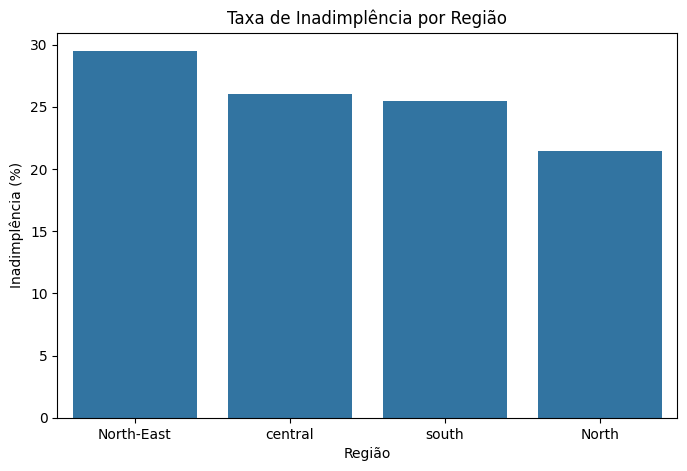

       Region     Status
0  North-East  29.474548
1     central  26.030292
2       south  25.441354
3       North  21.418392


In [ ]:
inad_regiao = df.groupby('Region')['Status'].mean().sort_values(ascending=False).reset_index()
inad_regiao['Status'] = inad_regiao['Status'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=inad_regiao, x='Region', y='Status')
plt.title("Taxa de Inadimplência por Região")
plt.xlabel("Região")
plt.ylabel("Inadimplência (%)")
plt.show()

print(inad_regiao)

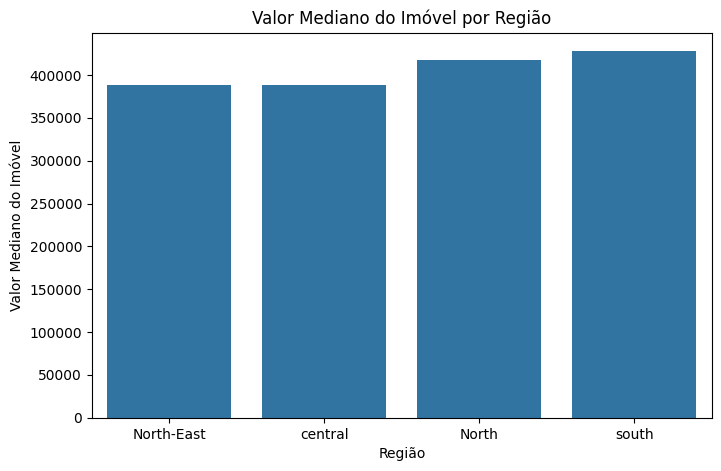

       Region  property_value
0  North-East        388000.0
1     central        388000.0
2       North        418000.0
3       south        428000.0


In [ ]:
imovel_regiao = df.groupby('Region')['property_value'].median().sort_values().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=imovel_regiao, x='Region', y='property_value')
plt.title("Valor Mediano do Imóvel por Região")
plt.xlabel("Região")
plt.ylabel("Valor Mediano do Imóvel")
plt.show()

print(imovel_regiao)

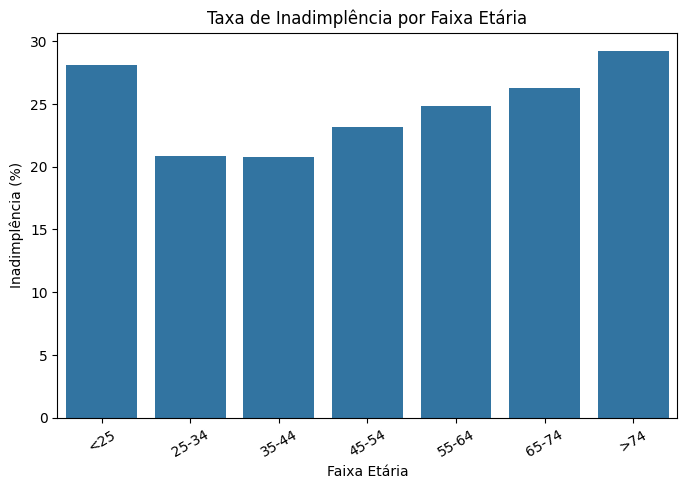

     age     Status
0  25-34  20.848169
1  35-44  20.775873
2  45-54  23.178017
3  55-64  24.833993
4  65-74  26.266161
5    <25  28.084784
6    >74  29.227734


In [ ]:
inad_idade = df.groupby('age', observed=False)['Status'].mean().reset_index()
inad_idade['Status'] = inad_idade['Status'] * 100

ordem_idade = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']

plt.figure(figsize=(8,5))
sns.barplot(data=inad_idade, x='age', y='Status', order=ordem_idade)
plt.title("Taxa de Inadimplência por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Inadimplência (%)")
plt.xticks(rotation=30)
plt.show()

print(inad_idade)

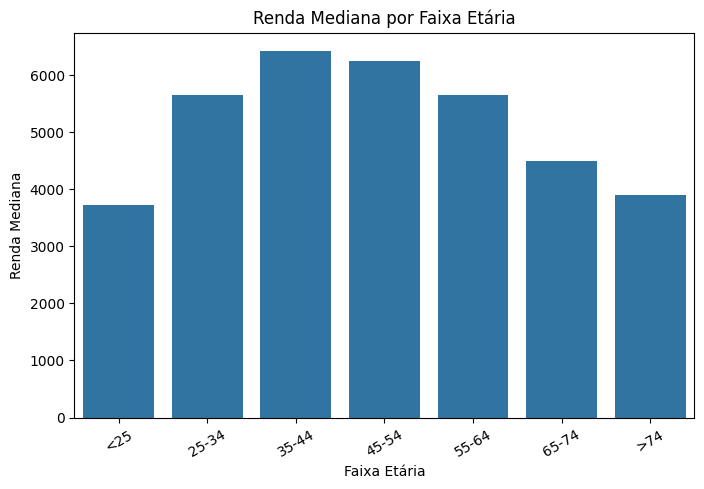

     age  income
0  25-34  5640.0
1  35-44  6420.0
2  45-54  6240.0
3  55-64  5640.0
4  65-74  4500.0
5    <25  3720.0
6    >74  3900.0


In [ ]:
renda_idade = df.groupby('age', observed=False)['income'].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=renda_idade, x='age', y='income', order=ordem_idade)
plt.title("Renda Mediana por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Renda Mediana")
plt.xticks(rotation=30)
plt.show()

print(renda_idade)

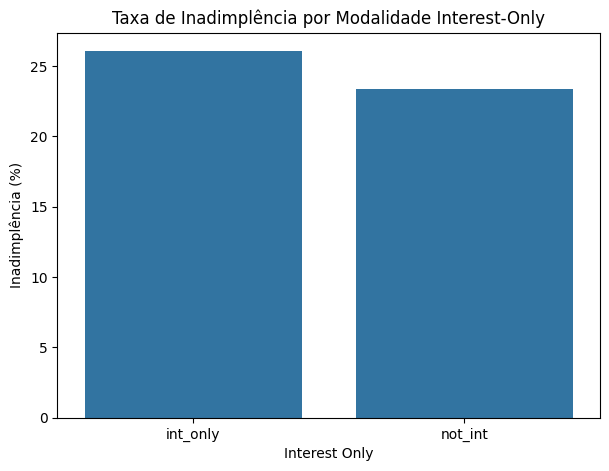

  interest_only     Status
0      int_only  26.058958
1       not_int  23.355570


In [ ]:
inad_interest = df.groupby('interest_only')['Status'].mean().reset_index()
inad_interest['Status'] = inad_interest['Status'] * 100

plt.figure(figsize=(7, 5))
sns.barplot(data=inad_interest, x='interest_only', y='Status')
plt.title("Taxa de Inadimplência por Modalidade Interest-Only")
plt.xlabel("Interest Only")
plt.ylabel("Inadimplência (%)")
plt.show()

print(inad_interest)

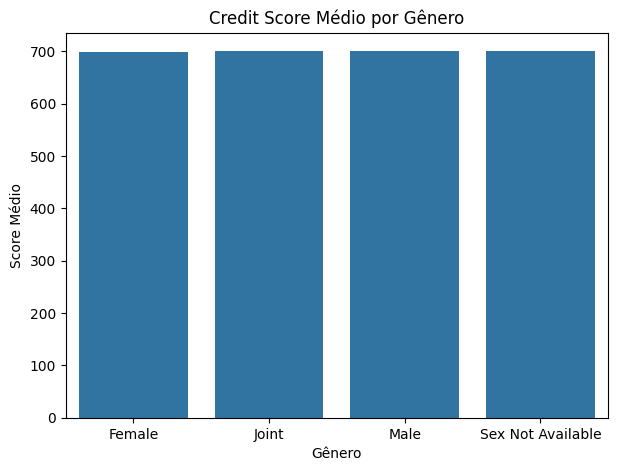

              Gender  Credit_Score
0             Female    698.825479
1              Joint    699.775416
2               Male    699.707774
3  Sex Not Available    700.473910


In [ ]:
score_genero = df.groupby('Gender')['Credit_Score'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=score_genero, x='Gender', y='Credit_Score')
plt.title("Credit Score Médio por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Score Médio")
plt.show()

print(score_genero)

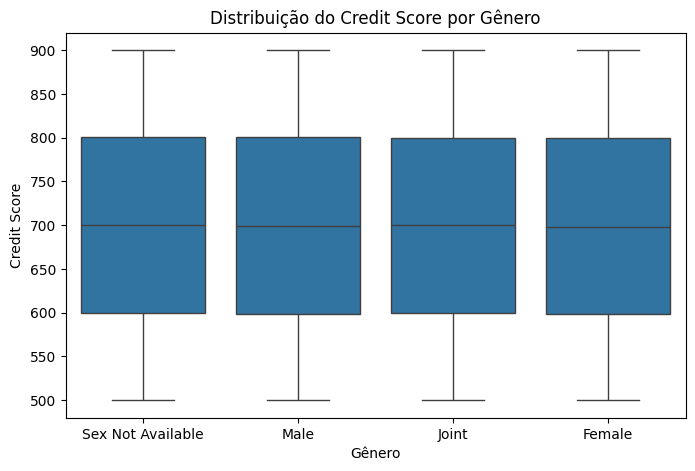

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Credit_Score')
plt.title("Distribuição do Credit Score por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Credit Score")
plt.show()

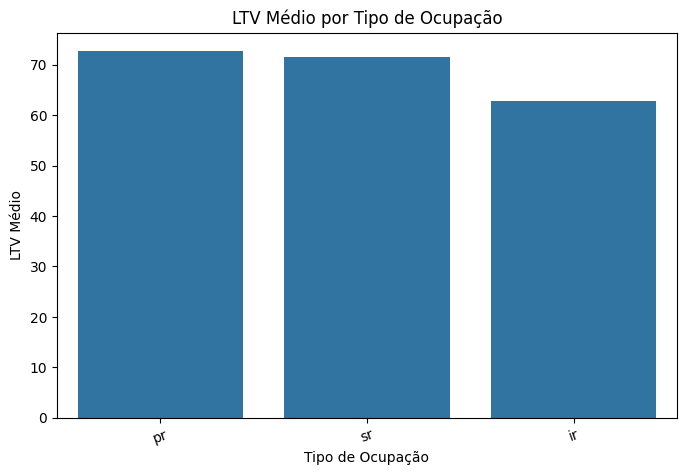

  occupancy_type        LTV
1             pr  72.740165
2             sr  71.498642
0             ir  62.817773


In [ ]:
ltv_ocup = df.groupby('occupancy_type')['LTV'].mean().reset_index().sort_values(by='LTV', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=ltv_ocup, x='occupancy_type', y='LTV')
plt.title("LTV Médio por Tipo de Ocupação")
plt.xlabel("Tipo de Ocupação")
plt.ylabel("LTV Médio")
plt.xticks(rotation=20)
plt.show()

print(ltv_ocup)

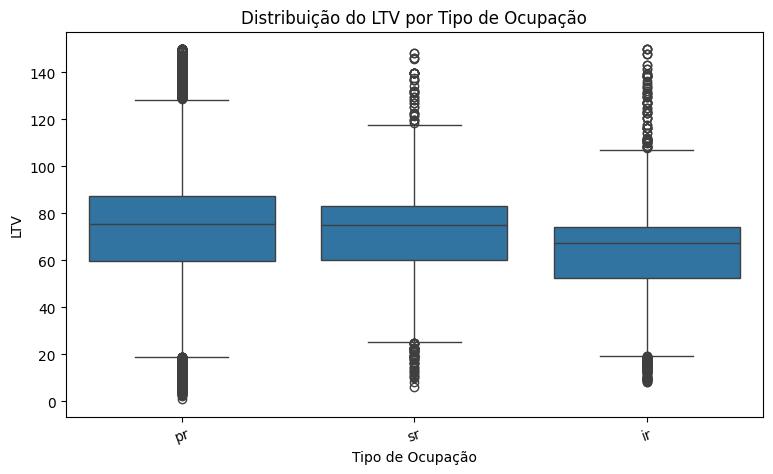

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='occupancy_type', y='LTV')
plt.title("Distribuição do LTV por Tipo de Ocupação")
plt.xlabel("Tipo de Ocupação")
plt.ylabel("LTV")
plt.xticks(rotation=20)
plt.show()

=== CORRELAÇÕES DE PEARSON ===
  LTV x Status: r=0.0344, p=1.62e-39, n=146398
  dtir1 x Status: r=0.0742, p=1.25e-177, n=146398
  Credit_Score x rate_of_interest: r=-0.0012, p=6.40e-01, n=146398
  loan_amount x Upfront_charges: r=0.0731, p=2.02e-172, n=146398
  Credit_Score x Status: r=0.0037, p=1.62e-01, n=146398
  rate_of_interest x Status: r=-0.0084, p=1.38e-03, n=146398


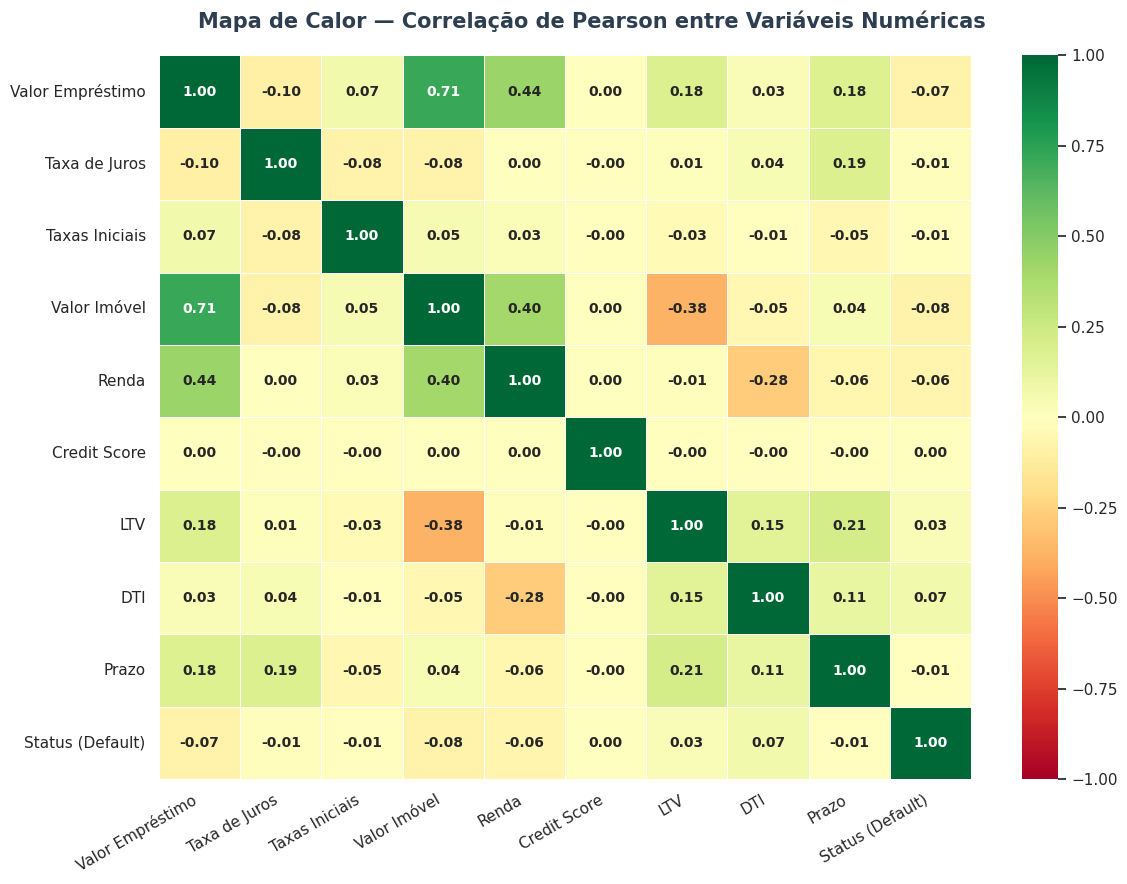

In [41]:
# =============================================================================
# ANÁLISE DE CORRELAÇÃO
# =============================================================================

df = df_clean

# ─── Configurações visuais ────────────────────────────────────────────────────
C0 = "#2ecc71"   # Adimplente
C1 = "#e74c3c"   # Inadimplente
BG = "#f8f9fa"
ACCENT = "#2c3e50"
OUT = "graficos_correlacao/"

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs(OUT, exist_ok=True)

# ─── Correlações de Pearson ───────────────────────────────────────────────────
print("=== CORRELAÇÕES DE PEARSON ===")
pairs = [
    ('LTV', 'Status'),
    ('dtir1', 'Status'),
    ('Credit_Score', 'rate_of_interest'),
    ('loan_amount', 'Upfront_charges'),
    ('Credit_Score', 'Status'),
    ('rate_of_interest', 'Status'),
]
for a, b in pairs:
    d = df[[a, b]].dropna()
    r, p = stats.pearsonr(d[a], d[b])
    print(f"  {a} x {b}: r={r:.4f}, p={p:.2e}, n={len(d)}")

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle("Mapa de Calor — Correlação de Pearson entre Variáveis Numéricas",
             fontsize=15, fontweight='bold', color=ACCENT)

num_cols = ['loan_amount','rate_of_interest','Upfront_charges','property_value',
            'income','Credit_Score','LTV','dtir1','term','Status']
corr = df[num_cols].corr(method='pearson')
labels = {
    'loan_amount': 'Valor Empréstimo', 'rate_of_interest': 'Taxa de Juros',
    'Upfront_charges': 'Taxas Iniciais', 'property_value': 'Valor Imóvel',
    'income': 'Renda', 'Credit_Score': 'Credit Score',
    'LTV': 'LTV', 'dtir1': 'DTI', 'term': 'Prazo', 'Status': 'Status (Default)'
}
corr.rename(index=labels, columns=labels, inplace=True)
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT + '12_heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()


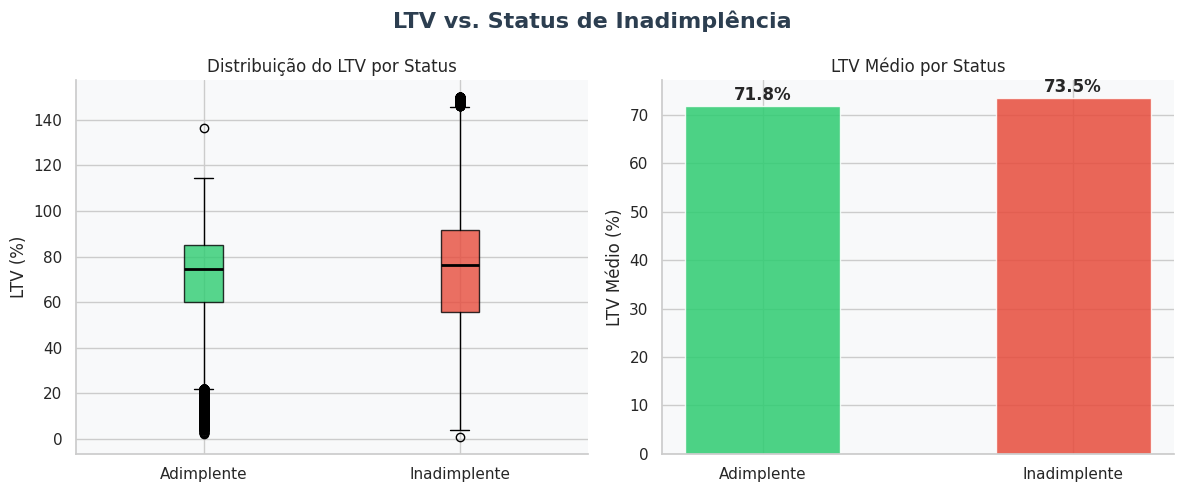

In [66]:
# ─── 1. LTV vs Status ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LTV vs. Status de Inadimplência", fontsize=16, fontweight='bold', color=ACCENT)

d = df[df['LTV'] < 200].copy()
d['Status_label'] = d['Status'].map({0: 'Adimplente', 1: 'Inadimplente'})

bp = axes[0].boxplot(
    [d[d['Status']==0]['LTV'].dropna(), d[d['Status']==1]['LTV'].dropna()],
    labels=['Adimplente', 'Inadimplente'],
    patch_artist=True, medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor(C0); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor(C1); bp['boxes'][1].set_alpha(0.8)
axes[0].set_title('Distribuição do LTV por Status')
axes[0].set_ylabel('LTV (%)')

means = d.groupby('Status_label')['LTV'].mean()
bars = axes[1].bar(means.index, means.values, color=[C0, C1], alpha=0.85, width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('LTV Médio por Status')
axes[1].set_ylabel('LTV Médio (%)')
plt.tight_layout()
plt.savefig(OUT + '01_ltv_vs_status.png', dpi=150, bbox_inches='tight')

plt.show()



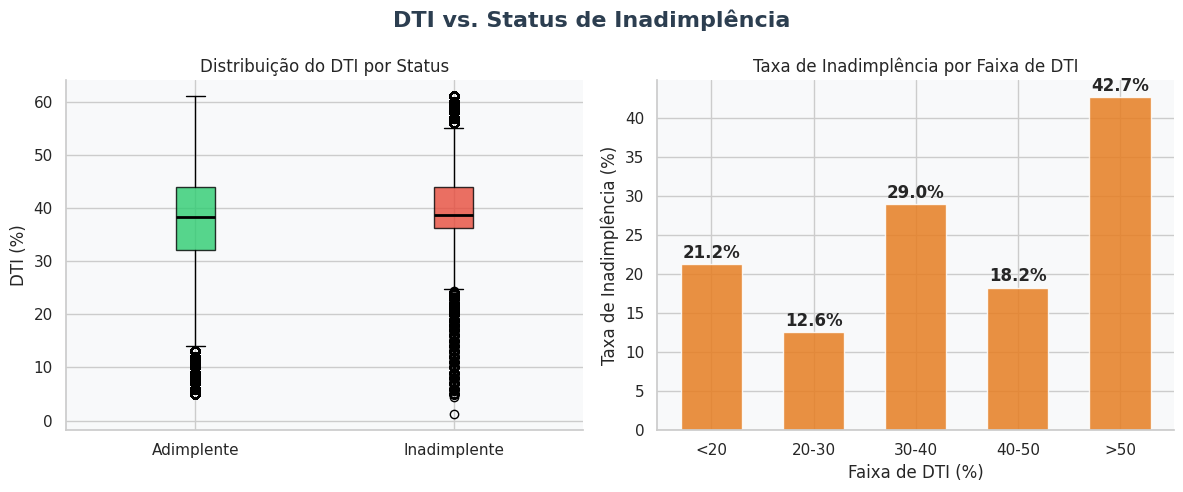

In [51]:
# ─── 2. DTI vs Status ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("DTI vs. Status de Inadimplência", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['dtir1', 'Status']].dropna()
d['Status_label'] = d['Status'].map({0: 'Adimplente', 1: 'Inadimplente'})

bp = axes[0].boxplot(
    [d[d['Status']==0]['dtir1'], d[d['Status']==1]['dtir1']],
    labels=['Adimplente', 'Inadimplente'],
    patch_artist=True, medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor(C0); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor(C1); bp['boxes'][1].set_alpha(0.8)
axes[0].set_title('Distribuição do DTI por Status')
axes[0].set_ylabel('DTI (%)')

d['dti_bucket'] = pd.cut(d['dtir1'], bins=[0,20,30,40,50,62],
                          labels=['<20','20-30','30-40','40-50','>50'])
dr = d.groupby('dti_bucket', observed=True)['Status'].mean() * 100
axes[1].bar(dr.index.astype(str), dr.values, color='#e67e22', alpha=0.85, width=0.6)
for i, val in enumerate(dr.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Taxa de Inadimplência por Faixa de DTI')
axes[1].set_ylabel('Taxa de Inadimplência (%)')
axes[1].set_xlabel('Faixa de DTI (%)')
plt.tight_layout()
plt.savefig(OUT + '02_dti_vs_status.png', dpi=150, bbox_inches='tight')

plt.show()

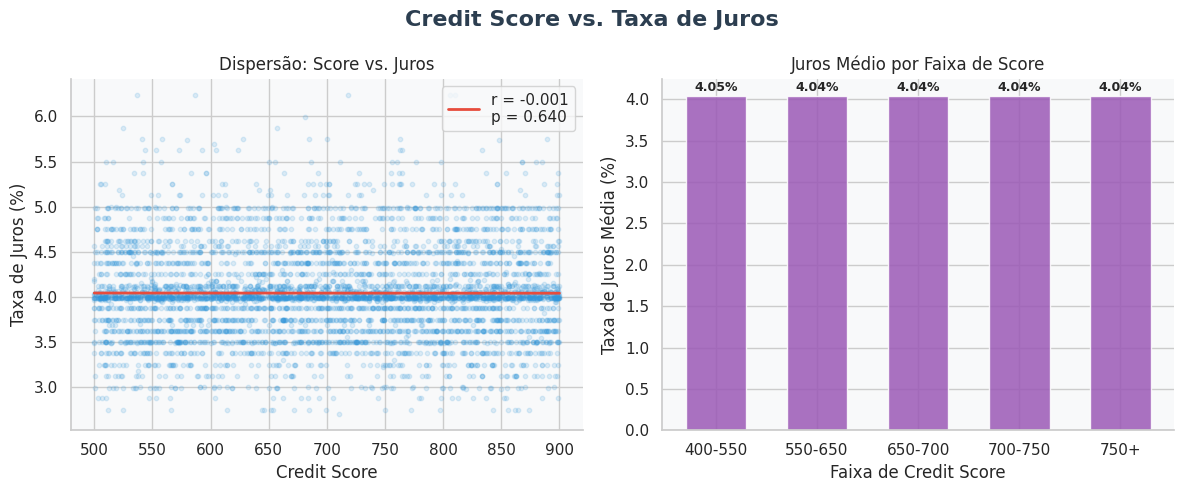

In [54]:
# ─── 3. Credit Score vs Taxa de Juros ─────────────────────────────────────────
import scipy.stats as stats # Re-import stats to ensure it refers to the scipy.stats module

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Credit Score vs. Taxa de Juros", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['Credit_Score', 'rate_of_interest']].dropna()
sample = d.sample(min(5000, len(d)), random_state=42)
axes[0].scatter(sample['Credit_Score'], sample['rate_of_interest'],
                alpha=0.15, color='#3498db', s=10)
m, b, r, p, se = stats.linregress(d['Credit_Score'], d['rate_of_interest'])
x_line = np.linspace(d['Credit_Score'].min(), d['Credit_Score'].max(), 200)
axes[0].plot(x_line, m*x_line+b, color='#e74c3c', linewidth=2,
             label=f'r = {r:.3f}\np = {p:.3f}')
axes[0].set_xlabel('Credit Score'); axes[0].set_ylabel('Taxa de Juros (%)')
axes[0].set_title('Dispersão: Score vs. Juros'); axes[0].legend()

d['score_bucket'] = pd.cut(d['Credit_Score'], bins=[400,550,650,700,750,900],
                             labels=['400-550','550-650','650-700','700-750','750+'])
mean_rate = d.groupby('score_bucket', observed=True)['rate_of_interest'].mean()
axes[1].bar(mean_rate.index.astype(str), mean_rate.values, color='#9b59b6', alpha=0.85, width=0.6)
for i, val in enumerate(mean_rate.values):
    axes[1].text(i, val + 0.02, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].set_title('Juros Médio por Faixa de Score')
axes[1].set_ylabel('Taxa de Juros Média (%)')
axes[1].set_xlabel('Faixa de Credit Score')
plt.tight_layout()
plt.savefig(OUT + '03_creditscore_vs_interest.png', dpi=150, bbox_inches='tight')
plt.show()

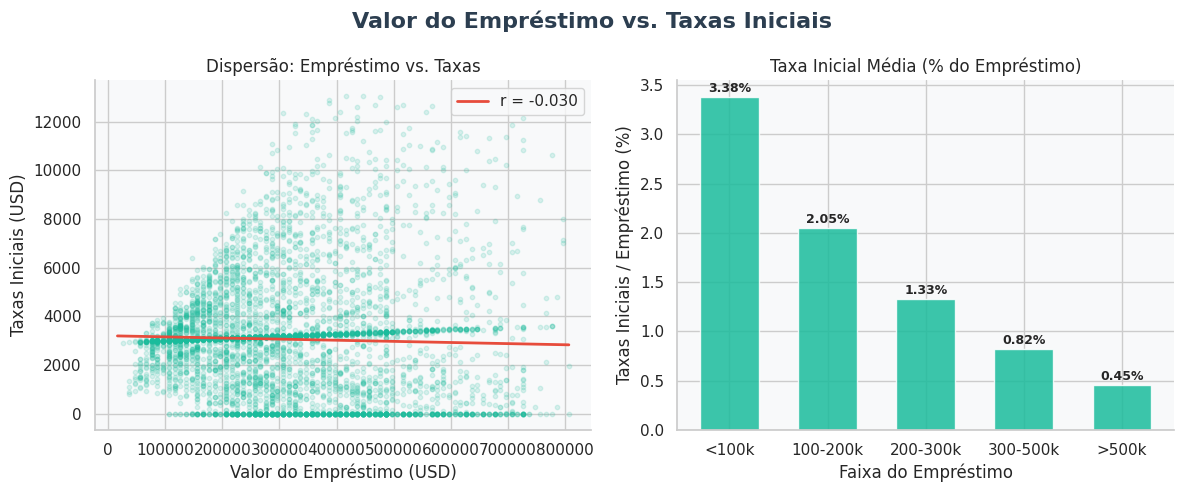

In [55]:
# ─── 4. Valor do Empréstimo vs. Taxas Iniciais ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Valor do Empréstimo vs. Taxas Iniciais", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['loan_amount', 'Upfront_charges']].dropna()
d = d[d['loan_amount'] < d['loan_amount'].quantile(0.99)]
d = d[d['Upfront_charges'] < d['Upfront_charges'].quantile(0.99)]
sample = d.sample(min(5000, len(d)), random_state=42)
axes[0].scatter(sample['loan_amount'], sample['Upfront_charges'], alpha=0.15, color='#1abc9c', s=10)
m, b, r, p, se = stats.linregress(d['loan_amount'], d['Upfront_charges'])
x_line = np.linspace(d['loan_amount'].min(), d['loan_amount'].max(), 200)
axes[0].plot(x_line, m*x_line+b, color='#e74c3c', linewidth=2, label=f'r = {r:.3f}')
axes[0].set_xlabel('Valor do Empréstimo (USD)'); axes[0].set_ylabel('Taxas Iniciais (USD)')
axes[0].set_title('Dispersão: Empréstimo vs. Taxas'); axes[0].legend()

d['charges_pct'] = (d['Upfront_charges'] / d['loan_amount']) * 100
d['loan_bucket'] = pd.cut(d['loan_amount'], bins=[0,100000,200000,300000,500000,10000000],
                            labels=['<100k','100-200k','200-300k','300-500k','>500k'])
mean_pct = d.groupby('loan_bucket', observed=True)['charges_pct'].mean()
axes[1].bar(mean_pct.index.astype(str), mean_pct.values, color='#1abc9c', alpha=0.85, width=0.6)
for i, val in enumerate(mean_pct.values):
    axes[1].text(i, val + 0.02, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].set_title('Taxa Inicial Média (% do Empréstimo)')
axes[1].set_ylabel('Taxas Iniciais / Empréstimo (%)')
axes[1].set_xlabel('Faixa do Empréstimo')
plt.tight_layout()
plt.savefig(OUT + '04_loanamount_vs_upfront.png', dpi=150, bbox_inches='tight')
plt.show()

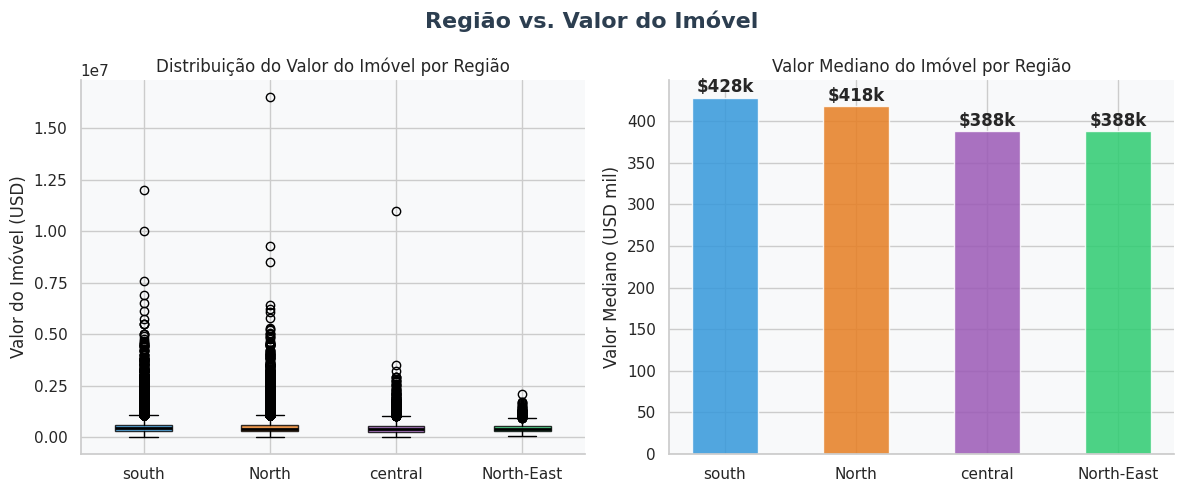

In [56]:
# ─── 5. Região vs. Valor do Imóvel ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Região vs. Valor do Imóvel", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['Region','property_value']].dropna()
regions = d['Region'].unique()
colors_r = ['#3498db','#e67e22','#9b59b6','#2ecc71']
data_r = [d[d['Region']==r]['property_value'].values for r in regions]
bp = axes[0].boxplot(data_r, labels=regions, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_r): patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_title('Distribuição do Valor do Imóvel por Região')
axes[0].set_ylabel('Valor do Imóvel (USD)')

medians_r = d.groupby('Region')['property_value'].median().reindex(regions)
bars = axes[1].bar(medians_r.index, medians_r.values / 1000, color=colors_r, alpha=0.85, width=0.5)
for bar, val in zip(bars, medians_r.values / 1000):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'${val:.0f}k', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Valor Mediano do Imóvel por Região')
axes[1].set_ylabel('Valor Mediano (USD mil)')
plt.tight_layout()
plt.savefig(OUT + '05_region_vs_propertyvalue.png', dpi=150, bbox_inches='tight')
plt.show()

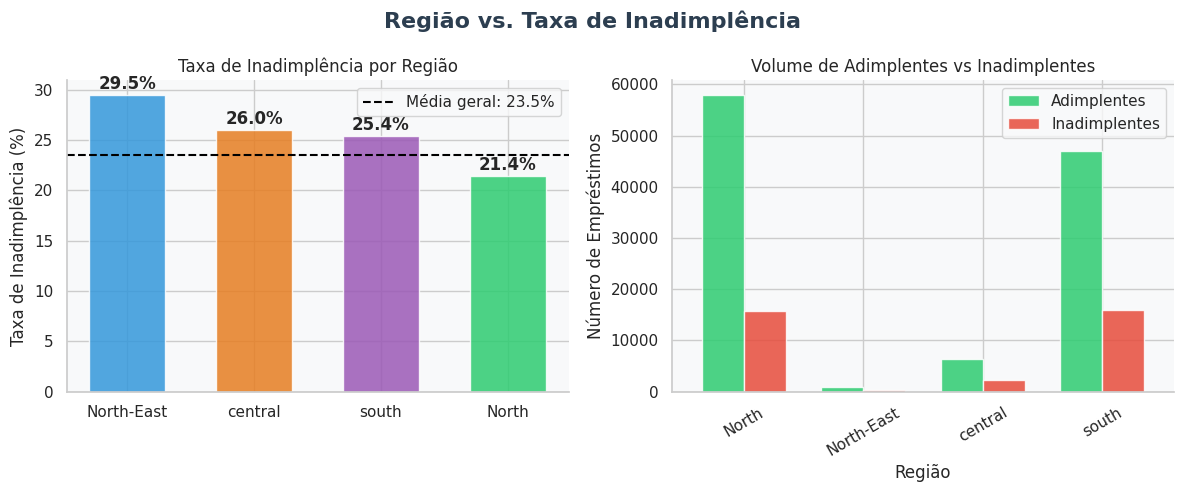

In [58]:
# ─── 6. Região vs. Taxa de Inadimplência ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Região vs. Taxa de Inadimplência", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['Region','Status']].dropna()
dr_reg = d.groupby('Region')['Status'].mean() * 100
dr_reg = dr_reg.sort_values(ascending=False)
bars = axes[0].bar(dr_reg.index, dr_reg.values, color=colors_r[:len(dr_reg)], alpha=0.85, width=0.6)
for bar, val in zip(bars, dr_reg.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].axhline(df['Status'].mean()*100, color='black', linestyle='--', linewidth=1.5,
                label=f'Média geral: {df["Status"].mean()*100:.1f}%')
axes[0].set_title('Taxa de Inadimplência por Região')
axes[0].set_ylabel('Taxa de Inadimplência (%)'); axes[0].legend()

count_reg = d.groupby(['Region','Status']).size().unstack()
count_reg.columns = ['Adimplentes','Inadimplentes']
count_reg.plot(kind='bar', ax=axes[1], color=[C0, C1], alpha=0.85, width=0.7)
axes[1].set_title('Volume de Adimplentes vs Inadimplentes')
axes[1].set_xlabel('Região'); axes[1].set_ylabel('Número de Empréstimos')
axes[1].tick_params(axis='x', rotation=30); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT + '06_region_vs_status.png', dpi=150, bbox_inches='tight')
plt.show()

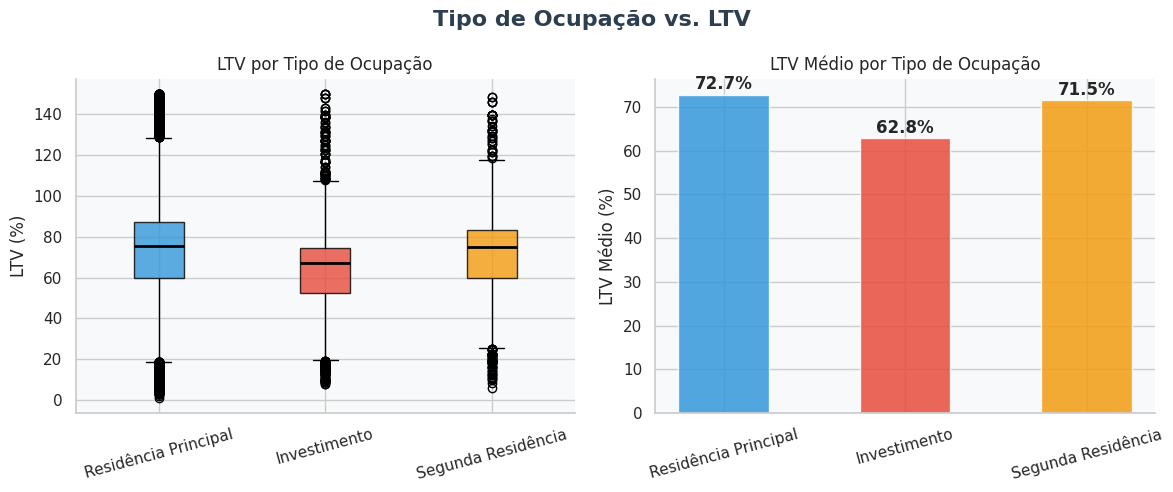

In [59]:
# ─── 7. Tipo de Ocupação vs. LTV ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Tipo de Ocupação vs. LTV", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['occupancy_type','LTV']].dropna()
d = d[d['LTV'] < 200]
occ_labels = {'pr': 'Residência Principal', 'ir': 'Investimento', 'sr': 'Segunda Residência'}
d['occ_label'] = d['occupancy_type'].map(occ_labels)
occ_order = ['Residência Principal', 'Investimento', 'Segunda Residência']
colors_o = ['#3498db','#e74c3c','#f39c12']
data_occ = [d[d['occ_label']==o]['LTV'].values for o in occ_order]
bp = axes[0].boxplot(data_occ, labels=occ_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_o): patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_title('LTV por Tipo de Ocupação'); axes[0].set_ylabel('LTV (%)')
axes[0].tick_params(axis='x', rotation=15)
means_o = d.groupby('occ_label')['LTV'].mean().reindex(occ_order)
bars = axes[1].bar(means_o.index, means_o.values, color=colors_o, alpha=0.85, width=0.5)
for bar, val in zip(bars, means_o.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('LTV Médio por Tipo de Ocupação'); axes[1].set_ylabel('LTV Médio (%)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(OUT + '07_occupancy_vs_ltv.png', dpi=150, bbox_inches='tight')
plt.show()

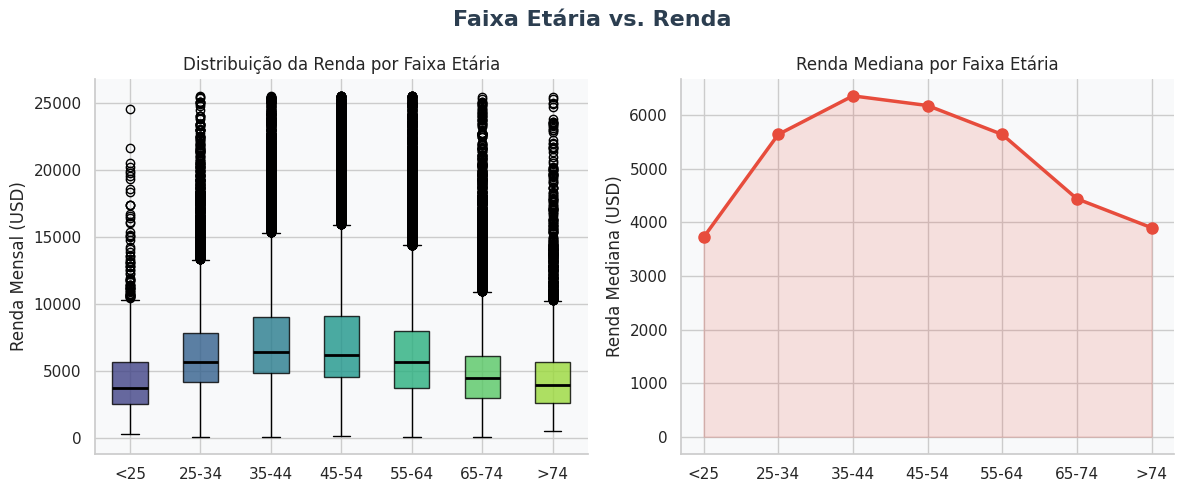

In [60]:
# ─── 8. Faixa Etária vs. Renda ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Faixa Etária vs. Renda", fontsize=16, fontweight='bold', color=ACCENT)

age_order = ['<25','25-34','35-44','45-54','55-64','65-74','>74']
d = df[['age','income']].dropna()
d = d[d['income'] < d['income'].quantile(0.99)]
d_filt = d[d['age'].isin(age_order)]
colors_age = plt.cm.viridis(np.linspace(0.2, 0.85, len(age_order)))
data_age = [d_filt[d_filt['age']==a]['income'].values for a in age_order]
bp = axes[0].boxplot(data_age, labels=age_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_age): patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_title('Distribuição da Renda por Faixa Etária'); axes[0].set_ylabel('Renda Mensal (USD)')
means_age = d_filt.groupby('age')['income'].median().reindex(age_order)
axes[1].plot(age_order, means_age.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(age_order)), means_age.values, alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(len(age_order))); axes[1].set_xticklabels(age_order)
axes[1].set_title('Renda Mediana por Faixa Etária'); axes[1].set_ylabel('Renda Mediana (USD)')
plt.tight_layout()
plt.savefig(OUT + '08_age_vs_income.png', dpi=150, bbox_inches='tight')
plt.show()

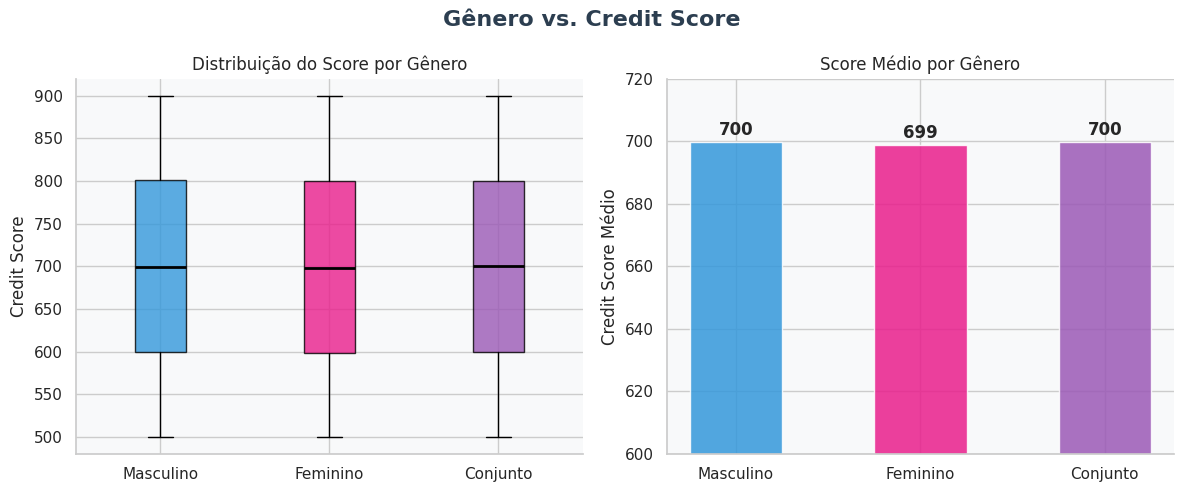

In [62]:
# ─── 9. Gênero vs. Credit Score ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gênero vs. Credit Score", fontsize=16, fontweight='bold', color=ACCENT)

d = df[df['Gender'].isin(['Male','Female','Joint'])][['Gender','Credit_Score']]
gender_colors = {'Male': '#3498db', 'Female': '#e91e8c', 'Joint': '#9b59b6'}
data_g = [d[d['Gender']==g]['Credit_Score'].values for g in ['Male','Female','Joint']]
bp = axes[0].boxplot(data_g, labels=['Masculino','Feminino','Conjunto'],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], gender_colors.values()): patch.set_facecolor(c); patch.set_alpha(0.8)
axes[0].set_title('Distribuição do Score por Gênero'); axes[0].set_ylabel('Credit Score')
means_g = d.replace({'Gender': {'Male':'Masculino','Female':'Feminino','Joint':'Conjunto'}}).groupby('Gender')['Credit_Score'].mean()
order_g = ['Masculino','Feminino','Conjunto']
means_g = means_g.reindex(order_g)
bars = axes[1].bar(means_g.index, means_g.values,
                   color=['#3498db','#e91e8c','#9b59b6'], alpha=0.85, width=0.5)
for bar, val in zip(bars, means_g.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Score Médio por Gênero'); axes[1].set_ylabel('Credit Score Médio')
axes[1].set_ylim(600, 720)
plt.tight_layout()
plt.savefig(OUT + '09_gender_vs_creditscore.png', dpi=150, bbox_inches='tight')
plt.show()

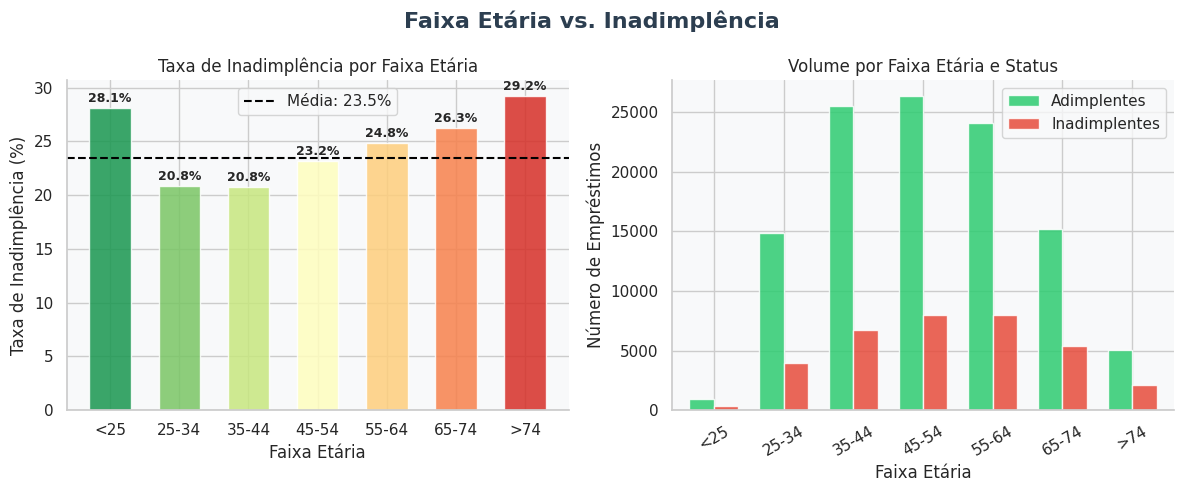

In [63]:
# ─── 10. Faixa Etária vs. Inadimplência ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Faixa Etária vs. Inadimplência", fontsize=16, fontweight='bold', color=ACCENT)

d = df[df['age'].isin(age_order)][['age','Status']]
dr_age = d.groupby('age')['Status'].mean() * 100
dr_age = dr_age.reindex(age_order)
bars = axes[0].bar(age_order, dr_age.values,
                   color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(age_order))), alpha=0.85, width=0.6)
for bar, val in zip(bars, dr_age.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].axhline(df['Status'].mean()*100, color='black', linestyle='--', linewidth=1.5,
                label=f'Média: {df["Status"].mean()*100:.1f}%')
axes[0].set_title('Taxa de Inadimplência por Faixa Etária')
axes[0].set_ylabel('Taxa de Inadimplência (%)'); axes[0].set_xlabel('Faixa Etária')
axes[0].legend()
count_age_d = d[d['Status']==1].groupby('age').size().reindex(age_order)
count_age_a = d[d['Status']==0].groupby('age').size().reindex(age_order)
stacked = pd.DataFrame({'Adimplentes': count_age_a, 'Inadimplentes': count_age_d})
stacked.plot(kind='bar', ax=axes[1], color=[C0, C1], alpha=0.85, width=0.7)
axes[1].set_title('Volume por Faixa Etária e Status')
axes[1].set_xlabel('Faixa Etária'); axes[1].set_ylabel('Número de Empréstimos')
axes[1].tick_params(axis='x', rotation=30); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT + '10_age_vs_status.png', dpi=150, bbox_inches='tight')
plt.show()

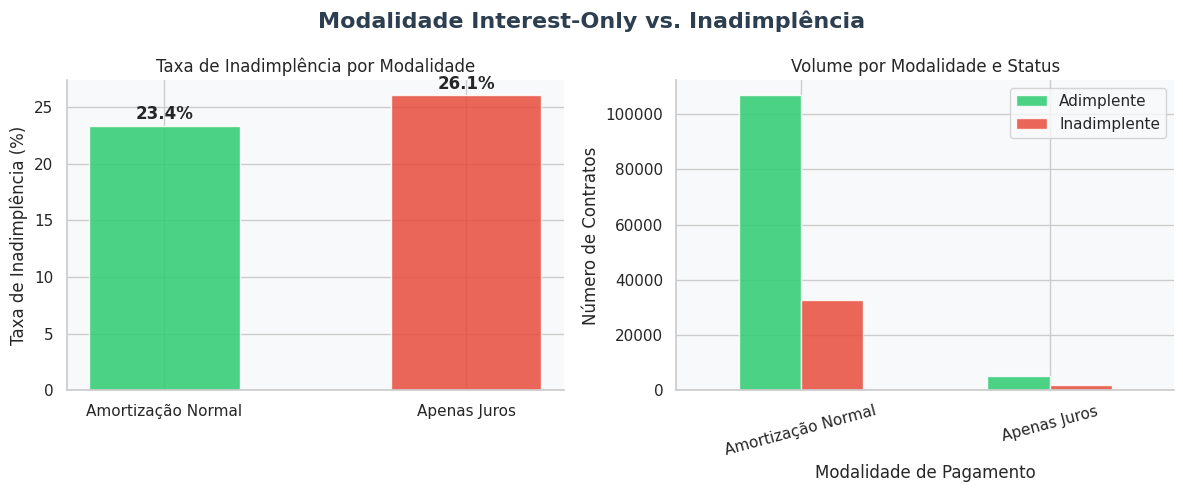

In [65]:
# ─── 11. Modalidade Interest-Only vs. Inadimplência ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Modalidade Interest-Only vs. Inadimplência", fontsize=16, fontweight='bold', color=ACCENT)

d = df[['interest_only','Status']].copy()
io_labels = {'not_int': 'Amortização Normal', 'int_only': 'Apenas Juros'}
d['io_label'] = d['interest_only'].map(io_labels)
dr_io = d.groupby('io_label')['Status'].mean() * 100
bars = axes[0].bar(dr_io.index, dr_io.values, color=['#2ecc71','#e74c3c'], alpha=0.85, width=0.5)
for bar, val in zip(bars, dr_io.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Taxa de Inadimplência por Modalidade'); axes[0].set_ylabel('Taxa de Inadimplência (%)')
count_io = d.groupby(['io_label','Status']).size().unstack()
count_io.columns = ['Adimplente','Inadimplente']
count_io.plot(kind='bar', ax=axes[1], color=[C0, C1], alpha=0.85, width=0.5)
axes[1].set_title('Volume por Modalidade e Status')
axes[1].set_xlabel('Modalidade de Pagamento'); axes[1].set_ylabel('Número de Contratos')
axes[1].tick_params(axis='x', rotation=15); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT + '11_interestonly_vs_status.png', dpi=150, bbox_inches='tight')
plt.show()